In [142]:
from torchvision import datasets
from torchvision.transforms import v2
import torch
from torch import nn
from torch.utils import data
from torchvision import models
from sklearn import model_selection
import matplotlib.pyplot as plt
import utils
import metrics
import tqdm
import functools

plt.style.use('default')

In [143]:
COLORS = [
    "#FF0000",  # Red
    "#00FF00",  # Green
	"#0000FF",  # Blue
    "#FFFF00",  # Yellow
    "#FF00FF",  # Magenta
    "#00FFFF",  # Cyan
	"#FFA500",  # Orange
    "#B1636F",  # Purple
    "#BED944",
    "#9792D4FF",
]

SEED = 0

COLORED_PROPORTIONS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]	# Proportions of colored images in train and val images used for experimenting
TRAIN_BS = 32
VAL_BS = 32

In [144]:
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "mps"

In [145]:
train_dataset = datasets.MNIST(root="./data", download=True)
test_dataset = datasets.MNIST(root="./data", train=False, download=True)

In [146]:
print(train_dataset)
print(test_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test


In [147]:
train_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)
test_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)

### Display proportions before train/val split

Text(0.5, 1.0, 'Train Dataset Label Distribution before splitting')

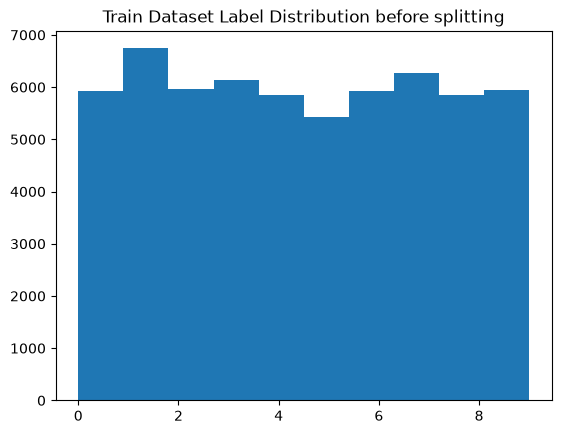

In [148]:
labels = torch.tensor([y for x, y in train_dataset])

plt.hist(labels, bins=10)
plt.title("Train Dataset Label Distribution before splitting")

In [149]:
train_split, val_split = model_selection.train_test_split(train_dataset, test_size=0.2, stratify=labels, random_state=SEED)

### Display proportions after train/val split

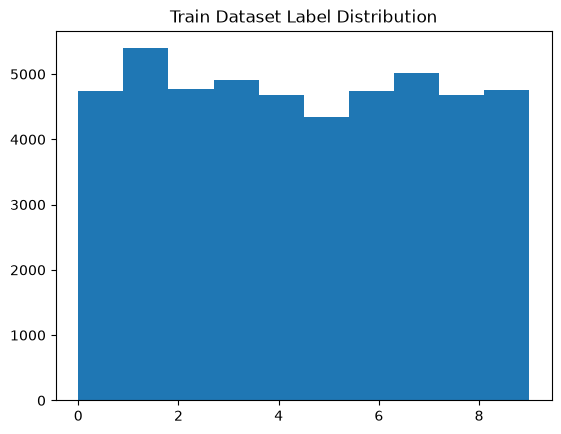

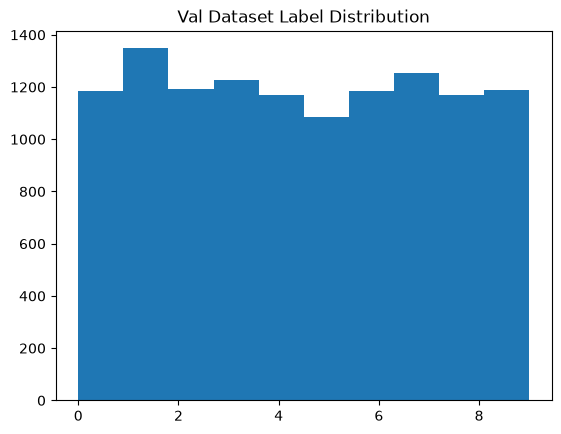

In [150]:
train_labels = torch.tensor([y for x, y in train_split])
val_labels = torch.tensor([y for x, y in val_split])

plt.hist(train_labels, bins=10)
plt.title("Train Dataset Label Distribution")
plt.show()

plt.hist(val_labels, bins=10)
plt.title("Val Dataset Label Distribution")
plt.show()

### Convert to torch dataset

In [151]:
class ColoredMNISTDataset(data.Dataset):
	"""Wrapper class that applies coloring based on the target class ID."""
	def __init__(self, dataset_list, transform=None, colored_proportions=0.95, colors_list=COLORS):
		"""
			Initialize 
		"""
		super().__init__()
		self.colors_list = colors_list
		self.pil_to_tensor = v2.Compose(
			[
				v2.ToImage(),
				v2.ToDtype(torch.float32, scale=True)
			]
		)

		self.x = []
		for x, y in dataset_list:
			if torch.rand(1).item() < colored_proportions:
				colored_image = self._gray_to_colored(self.pil_to_tensor(x), y)
				self.x.append(colored_image)
			else:
				w, h = x.size
				self.x.append(self.pil_to_tensor(x).expand(1, 3, w, h))

		self.x = torch.cat(self.x, dim=0)
		self.y = torch.tensor([y for x, y in dataset_list])
		self.transform = transform

	def __len__(self):
		return len(self.x)
	
	def __getitem__(self, index):
		if self.transform is not None:
			return self.transform(self.x[index]), self.y[index]
		return self.x[index], self.y[index]
	
	def _gray_to_colored(self, x, y):
		assert len(self.colors_list) > y, f"Color index {y} is out of range for COLORS list."

		color = self.colors_list[y]
		colored_image = torch.zeros(3, x.shape[1], x.shape[2])
		colored_image[0] = x * int(color[1:3], 16) / 255.0
		colored_image[1] = x * int(color[3:5], 16) / 255.0
		colored_image[2] = x * int(color[5:7], 16) / 255.0
		return colored_image.unsqueeze(0)

In [152]:
class Model(nn.Module):
	def __init__(self, n_classes=10):
		super().__init__()
		self.fc = nn.Sequential(
			nn.Flatten(),
			nn.Linear(3*784, 2048),
			nn.Tanh(),
			nn.Linear(2048, 512),
			nn.Tanh(),
			nn.Linear(512, 64),
			nn.Tanh(),
			nn.Linear(64, n_classes)
		)

	def forward(self, x):
		return self.fc(x)		

In [153]:
def train_one_epoch(model, train_dl, criterion, optimizer, metrics_calculator, device="cuda"):
	"""
	Performs the optimization over the whole dataset once.
	Resets the metrics_calculator at the beggining and updates metrics inplace but does not return the metrics directly.
	Those can be accesed outside of this function.

	Args:
		model: Model trained.
		train_dl: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used for updating model's weights.
		metrics_calculator: Instance of metrics calculator used for computing metrics on train dataset.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean training loss for current epoch.
	"""

	metrics_calculator.reset()
	model.train()
	train_epoch_loss = 0
	n_instances = 0
	
	for inputs, targets in tqdm.tqdm(train_dl, desc="Training"):
		optimizer.zero_grad()

		inputs = inputs.to(device)
		targets = targets.to(device)

		outputs = model(inputs)

		loss = criterion(outputs, targets)
		loss.backward()
		optimizer.step()

		train_epoch_loss += loss.item()
		metrics_calculator.update(outputs.detach(), targets.detach())
		n_instances += inputs.shape[0]
	
	mean_epoch_loss = train_epoch_loss / n_instances
	return mean_epoch_loss

@torch.no_grad()
def evaluate(model, dataloader, criterion, metrics_calculator, device="cuda"):
	"""
	Evaluates the model given a dataloader

	Args:
		model: Model to evaluate.
		dataloader: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		metrics_calculator: Instance of metrics calculator used for computing metrics.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean loss.
	"""

	metrics_calculator.reset()
	model.eval()
	total_loss = 0
	n_instances = 0
	
	for inputs, targets in tqdm.tqdm(dataloader, desc="Evaluating"):
		inputs = inputs.to(device)
		targets = targets.to(device)

		outputs = model(inputs)

		loss = criterion(outputs, targets)

		total_loss += loss.item()
		metrics_calculator.update(outputs.detach(), targets.detach())
		n_instances += inputs.shape[0]
	
	mean_loss = total_loss / n_instances
	return mean_loss


def train(model, train_dl, val_dl, criterion, optimizer, metrics_calculator, epochs=10, device="cuda"):
	"""
	Trains the model for the specified number of epochs.

	Args:
		model: Model trained.
		train_dl: Dataloader with training data.
		val_dl: Dataloader with validation data.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used to update model parameters.
		metrics_calculator: Instance of metrics calculator used for computing metrics.
		epochs (optional): Number of epochs to train the model for.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		list[float]: List of training loss in each epoch.
		list[float]: List of validation loss in each epoch.
	"""
	best_weights = model.state_dict()
	best_val_loss = float("inf")
	train_losses = []
	val_losses = []

	for epoch in range(epochs):
		train_loss = train_one_epoch(model, train_dl, criterion, optimizer, metrics_calculator, device)
		accuracy, precision, recall, f1_score, auprc, auroc = metrics_calculator.compute_all()
		val_loss = evaluate(model, val_dl, criterion, metrics_calculator, device)
		accuracy, precision, recall, f1_score, auprc, auroc = metrics_calculator.compute_all()

		print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}, AUPRC: {auprc:.4f}, AUROC: {auroc:.4f}")

		train_losses.append(train_loss)
		val_losses.append(val_loss)

		if val_loss < best_val_loss:
			best_val_loss = val_loss
			best_weights = model.state_dict()

	model.load_state_dict(best_weights)

	return train_losses, val_losses

Proportion of colored images: 0.95


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 210.11it/s]


Epoch 1/10 - Train Loss: 0.0023, Val Loss: 0.0008, Accuracy: 0.9922, Precision: 0.9922, Recall: 0.9922, F1 Score: 0.9922, AUPRC: 0.9988, AUROC: 0.9996


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 192.08it/s]


Epoch 2/10 - Train Loss: 0.0009, Val Loss: 0.0008, Accuracy: 0.9921, Precision: 0.9921, Recall: 0.9921, F1 Score: 0.9921, AUPRC: 0.9988, AUROC: 0.9996


...

Epoch 8/10 - Train Loss: 0.0004, Val Loss: 0.0007, Accuracy: 0.9941, Precision: 0.9941, Recall: 0.9941, F1 Score: 0.9941, AUPRC: 0.9985, AUROC: 0.9994


Evaluating: 100%|██████████| 375/375 [00:02<00:00, 137.55it/s]


Epoch 9/10 - Train Loss: 0.0004, Val Loss: 0.0007, Accuracy: 0.9938, Precision: 0.9938, Recall: 0.9938, F1 Score: 0.9938, AUPRC: 0.9986, AUROC: 0.9996


Evaluating: 100%|██████████| 375/375 [00:02<00:00, 155.44it/s]


Epoch 10/10 - Train Loss: 0.0004, Val Loss: 0.0005, Accuracy: 0.9948, Precision: 0.9948, Recall: 0.9948, F1 Score: 0.9948, AUPRC: 0.9985, AUROC: 0.9995


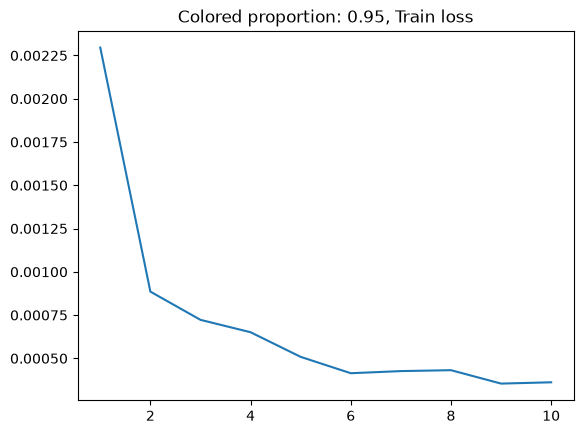

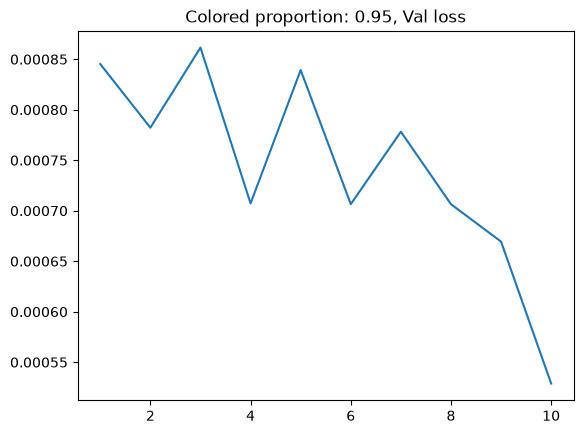

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 220.92it/s]

Performance on clean validation set:
Clean Val Loss: 0.0109, Accuracy: 0.9032, Precision: 0.9032, Recall: 0.9032, F1 Score: 0.9032, AUPRC: 0.9361, AUROC: 0.9854
Performance on fully colored validation set:
Colored Val Loss: 0.0001, Accuracy: 0.9995, Precision: 0.9995, Recall: 0.9995, F1 Score: 0.9995, AUPRC: 1.0000, AUROC: 1.0000


In [154]:
metrics_calculator = metrics.MetricsCalculator(num_classes=len(train_labels.unique()))

model_weights = [] # Best weights for each colored proportion

for proportion in COLORED_PROPORTIONS[-2:-1]:
	print(f"Proportion of colored images: {proportion}")
	metrics_calculator.reset()
	
	train_dataset = ColoredMNISTDataset(train_split, colored_proportions=proportion)
	val_dataset = ColoredMNISTDataset(val_split, colored_proportions=proportion)
	clean_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=0)
	colored_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=1)

	train_dataloader = data.DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
	val_dataloader = data.DataLoader(val_dataset, batch_size=VAL_BS)
	clean_val_dataloader = data.DataLoader(clean_val_dataset, batch_size=VAL_BS)
	colored_val_dataloader = data.DataLoader(colored_val_dataset, batch_size=VAL_BS)

	model = Model()
	model.to(device)

	optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
	criterion = nn.CrossEntropyLoss()

	# Train the model
	train_losses, val_losses = train(model, train_dataloader, val_dataloader, criterion, optimizer, metrics_calculator, device=device)

	# Save model weights in list to reuse later
	model_weights.append(model.state_dict())
	
	# Plot results
	utils.plot_loss(train_losses, f"Colored proportion: {proportion}, Train loss")
	utils.plot_loss(val_losses, f"Colored proportion: {proportion}, Val loss")

	# Evaluate the model on clean validation dataset
	clean_val_loss = evaluate(model, clean_val_dataloader, criterion, metrics_calculator, device)
	clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

	# Evaluate the model on fully colored validation dataset
	colored_val_loss = evaluate(model, colored_val_dataloader, criterion, metrics_calculator, device)
	colored_val_accuracy, colored_val_precision, colored_val_recall, colored_val_f1_score, colored_val_auprc, colored_val_auroc = metrics_calculator.compute_all()

	print("Performance on clean validation set:")
	print(f"Clean Val Loss: {clean_val_loss:.4f}, Accuracy: {clean_val_accuracy:.4f}, Precision: {clean_val_precision:.4f}, Recall: {clean_val_recall:.4f}, F1 Score: {clean_val_f1_score:.4f}, AUPRC: {clean_val_auprc:.4f}, AUROC: {clean_val_auroc:.4f}")
	print("Performance on fully colored validation set:")
	print(f"Colored Val Loss: {colored_val_loss:.4f}, Accuracy: {colored_val_accuracy:.4f}, Precision: {colored_val_precision:.4f}, Recall: {colored_val_recall:.4f}, F1 Score: {colored_val_f1_score:.4f}, AUPRC: {colored_val_auprc:.4f}, AUROC: {colored_val_auroc:.4f}")


In [155]:
# model.load_state_dict(model_weights[-2])
model.load_state_dict(model_weights[-1])
model.eval()

Model(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=2048, bias=True)
    (2): Tanh()
    (3): Linear(in_features=2048, out_features=512, bias=True)
    (4): Tanh()
    (5): Linear(in_features=512, out_features=64, bias=True)
    (6): Tanh()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [156]:
# Evaluate the model on clean validation dataset
clean_val_loss = evaluate(model, clean_val_dataloader, criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
colored_val_loss = evaluate(model, colored_val_dataloader, criterion, metrics_calculator, device)
colored_val_accuracy, colored_val_precision, colored_val_recall, colored_val_f1_score, colored_val_auprc, colored_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss:.4f}, Accuracy: {clean_val_accuracy:.4f}, Precision: {clean_val_precision:.4f}, Recall: {clean_val_recall:.4f}, F1 Score: {clean_val_f1_score:.4f}, AUPRC: {clean_val_auprc:.4f}, AUROC: {clean_val_auroc:.4f}")
print("Performance on fully colored validation set:")
print(f"Colored Val Loss: {colored_val_loss:.4f}, Accuracy: {colored_val_accuracy:.4f}, Precision: {colored_val_precision:.4f}, Recall: {colored_val_recall:.4f}, F1 Score: {colored_val_f1_score:.4f}, AUPRC: {colored_val_auprc:.4f}, AUROC: {colored_val_auroc:.4f}")

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 244.01it/s]

Performance on clean validation set:
Clean Val Loss: 0.0109, Accuracy: 0.9032, Precision: 0.9032, Recall: 0.9032, F1 Score: 0.9032, AUPRC: 0.9361, AUROC: 0.9854
Performance on fully colored validation set:
Colored Val Loss: 0.0001, Accuracy: 0.9995, Precision: 0.9995, Recall: 0.9995, F1 Score: 0.9995, AUPRC: 1.0000, AUROC: 1.0000


In [157]:
colors_flipped_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=1, colors_list=COLORS[::-1])
colors_flipped_val_dataloader = torch.utils.data.DataLoader(colors_flipped_val_dataset, batch_size=VAL_BS, shuffle=False)

colors_flipped_val_loss = evaluate(model, colors_flipped_val_dataloader, criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss:.4f}, Accuracy: {colors_flipped_val_accuracy:.4f}, Precision: {colors_flipped_val_precision:.4f}, Recall: {colors_flipped_val_recall:.4f}, F1 Score: {colors_flipped_val_f1_score:.4f}, AUPRC: {colors_flipped_val_auprc:.4f}, AUROC: {colors_flipped_val_auroc:.4f}")

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 238.97it/s]

Performance on validation set with colors flipped:
Colors flipped Val Loss: 0.1945, Accuracy: 0.3410, Precision: 0.3410, Recall: 0.3410, F1 Score: 0.3410, AUPRC: 0.3386, AUROC: 0.6948


# Sparse autoencoder

In [158]:
SAE_BS = 1024
SAE_ALPHA = 1 # Used to balance between reconstruction and sparsity loss
SAE_TOPK = 5
SAE_HIDDEN_DIM = 256

In [159]:
class SAE(nn.Module):
	"""Sparse autoencoder built from simple Linear layers."""
	def __init__(self, n_inputs: int, n_hidden: int) -> None:
		"""
		Initialize function.

		Args:
			n_inputs: Shape of input layer.
			n_hidden: Shape of hidden vector.
		"""
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Linear(n_inputs, n_hidden),
			nn.ReLU()
		)
		self.decoder = nn.Linear(n_hidden, n_inputs)
		
	def encode(self, x: torch.Tensor) -> torch.Tensor:
		"""
		Encodes the input using using encoder layer.

		Args:
			x: Input tensor.
		Returns:
			torch.Tensor: Autoencoder hidden vector.
		"""
		return self.encoder(x)

	def decode(self, hidden: torch.Tensor) -> torch.Tensor:
		"""
		Decodes the input using using decoder layer.

		Args:
			hidden: Hidden vector which is an output of the encoder layer.
		Returns:
			torch.Tensor: Reconstructed output.
		"""
		return self.decoder(hidden)		

	def forward(self, x):
		"""
		Forward function that encodes the input and reconstructs it using decoder.

		Args:
			x: Input tensor.

		Returns:
			torch.Tensor: Reconstructed input.
			torch.Tensor: Hidden vector which is an output of the encoder layer.
		"""
		hidden = self.encode(x)
		output = self.decode(hidden)
		return output, hidden

In [160]:
class TopkSAE(nn.Module):
	"""Sparse autoencoder built from simple Linear layers."""
	def __init__(self, n_inputs: int, n_hidden: int, topk: int) -> None:
		"""
		Initialize function.

		Args:
			n_inputs: Shape of input layer.
			n_hidden: Shape of hidden vector.
		"""
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Linear(n_inputs, n_hidden),
			nn.ReLU()
		)
		self.decoder = nn.Linear(n_hidden, n_inputs)
		self.topk = topk
		self.hidden_dim = n_hidden
		
	def encode(self, x: torch.Tensor) -> torch.Tensor:
		"""
		Encodes the input using using encoder layer. Doesn't apply topk.

		Args:
			x: Input tensor.
		Returns:
			torch.Tensor: Autoencoder hidden vector.
		"""
		return self.encoder(x)

	def decode(self, hidden: torch.Tensor) -> torch.Tensor:
		"""
		Decodes the input using using decoder layer.

		Args:
			hidden: Hidden vector which is an output of the encoder layer.
		Returns:
			torch.Tensor: Reconstructed output.
		"""
		return self.decoder(hidden)		

	def forward(self, x):
		"""
		Forward function that encodes the input, applies topk and reconstructs it using decoder.

		Args:
			x: Input tensor.

		Returns:
			torch.Tensor: Reconstructed input.
			torch.Tensor: Sparse hidden vector which is an output of the encoder layer.
		"""
		hidden = self.encode(x)

		values, indices = torch.topk(hidden, self.topk, dim=1)
		sparse_hidden = torch.zeros_like(hidden)
		sparse_hidden.scatter_(1, indices, values)

		output = self.decode(sparse_hidden)
		return output, sparse_hidden

In [161]:
sae_input_shape = model.fc[-1].in_features

In [162]:
@torch.no_grad()
def generate_sae_dataset(model: nn.Module, dataset: data.Dataset) -> data.TensorDataset:
	"""
	Function for generating SAE dataset based on a model and a dataset.
	Uses model's last layer input as a reconstruction target for SAE.

	Args:
		model: Model which embeddings are to be extracted.
		dataset: Dataset with input images to be encoded by the model.

	Returns:
		data.TensorDataset: SAE dataset with encoded images.
	"""
	sae_input_shape = model.fc[-1].in_features
	sae_dataset = torch.empty(len(dataset), sae_input_shape)

	idx = 0
	for inputs, targets in tqdm.tqdm(dataset):
		inputs = inputs.to(device)
		inputs = inputs.unsqueeze(0)
		outputs = model.fc[:-1](inputs).squeeze()
		sae_dataset[idx] = outputs
		idx += 1

	return data.TensorDataset(sae_dataset)

In [163]:
sae_train_dataset = generate_sae_dataset(model, train_dataset)
sae_val_dataset = generate_sae_dataset(model, val_dataset)

sae_train_dataloader = data.DataLoader(sae_train_dataset, SAE_BS, shuffle=True)
sae_val_dataloader = data.DataLoader(sae_val_dataset, SAE_BS, shuffle=False)

100%|██████████| 12000/12000 [00:30<00:00, 399.24it/s]


In [164]:
def sae_train_one_epoch(model, train_dl, criterion, optimizer, device="cuda"):
	"""
	Performs the SAE optimization over the whole dataset once.

	Args:
		model: Model trained.
		train_dl: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used for updating model's weights.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean training loss for current epoch.
		float: Mean number of active hidden vector neurons in each batch.
	"""

	model.train()
	train_epoch_loss = 0
	total_active_neurons = 0
	n_instances = 0

	is_topk = isinstance(criterion, nn.MSELoss)
	
	for sae_inputs in tqdm.tqdm(train_dl, desc="Training"):
		optimizer.zero_grad()

		# data.TensorDataset returns list of len 1 so this retrieves all batches as torch.Tensor
		sae_inputs = sae_inputs[0].to(device)

		outputs, hidden = model(sae_inputs)

		if is_topk:
			loss = criterion(outputs, sae_inputs)
		else:
			loss = criterion(outputs, sae_inputs, hidden)

		active_neurons = torch.sum(hidden > 0)

		loss.backward()
		optimizer.step()

		train_epoch_loss += loss.item()
		total_active_neurons += active_neurons.item()
		n_instances += sae_inputs.shape[0]
	
	mean_epoch_loss = train_epoch_loss / n_instances
	mean_active_neurons = total_active_neurons / n_instances
	return mean_epoch_loss, mean_active_neurons

@torch.no_grad()
def sae_evaluate(model, dataloader, criterion, device="cuda"):
	"""
	Evaluates SAE given a dataloader

	Args:
		model: Model to evaluate.
		dataloader: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean loss.
		float: Mean number of active hidden vector neurons in each batch.
	"""

	model.eval()
	total_loss = 0
	total_active_neurons = 0
	n_instances = 0

	is_topk = isinstance(criterion, nn.MSELoss)
	
	for sae_inputs in tqdm.tqdm(dataloader, desc="Evaluating"):
		# data.TensorDataset returns list of len 1 so this retrieves all batches as torch.Tensor
		sae_inputs = sae_inputs[0].to(device)

		outputs, hidden = model(sae_inputs)

		if is_topk:
			loss = criterion(outputs, sae_inputs)
		else:
			loss = criterion(outputs, sae_inputs, hidden)

		active_neurons = torch.sum(hidden > 0)

		total_loss += loss.item()
		total_active_neurons += active_neurons.item()
		n_instances += sae_inputs.shape[0]
	
	mean_loss = total_loss / n_instances
	mean_active_neurons = total_active_neurons / n_instances
	return mean_loss, mean_active_neurons

def sae_train(model, train_dl, val_dl, criterion, optimizer, epochs=10, device="cuda"):
	"""
	Function to train SAE model using dataset with embeddings from image classification model.

	Args:
		model: SAE model to train.
		train_dl: Dataset with training embeddings.
		val_dl: Dataset with validation embeddings.
		criterion: Criterion used to calculate SAE loss.
		optimizer: Optimizer used to update SAE params.
		epochs (optional): Number of epochs to train SAE for.
		device (optional): Device used for calculations like CUDA or CPU.
	"""

	best_weights = model.state_dict()
	best_val_loss = float("inf")
	train_losses = []
	val_losses = []

	for epoch in range(epochs):
		train_loss, train_mean_active_neurons = sae_train_one_epoch(model, train_dl, criterion, optimizer, device)
		val_loss, val_mean_active_neurons = sae_evaluate(model, val_dl, criterion, device)

		print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train active neurons: {train_mean_active_neurons:.4f}, Val active neurons: {val_mean_active_neurons:.4f}")

		train_losses.append(train_loss)
		val_losses.append(val_loss)

		if val_loss < best_val_loss:
			best_val_loss = val_loss
			best_weights = model.state_dict()

	model.load_state_dict(best_weights)

	return train_losses, val_losses

In [165]:
def sae_criterion_fn(outputs, targets, hidden, alpha=0.5):
    """
    SAE criterion that applies both L1 loss on hidden SAE vector as well as L2 reconstruction loss.
    
    Args:
		outputs: Output of the SAE decoder.
        targets: Target used for reconstruction loss.
        hidden: Sparse hidden vector, output of the SAE's encoder.
        alpha (optional): Weight applied to sparsity loss.
    Returns:
		torch.Tensor: Combined sparsity and reconstruction loss.
    """
    mae = torch.mean(torch.abs(hidden))	# L1 Loss to ensure hidden layer sparsity
    reconstruction_loss = torch.mean((outputs-targets)**2)
    return reconstruction_loss+alpha*mae

In [166]:
sae_model = TopkSAE(sae_input_shape, SAE_HIDDEN_DIM, topk=SAE_TOPK)
sae_model.to(device)
sae_optimizer = torch.optim.Adam(sae_model.parameters(), lr=1e-3)
# sae_criterion = functools.partial(sae_criterion_fn, alpha=SAE_ALPHA)
sae_criterion = nn.MSELoss()

In [167]:
sae_train(sae_model, sae_train_dataloader, sae_val_dataloader, sae_criterion, sae_optimizer, epochs=30, device=device)

Evaluating: 100%|██████████| 12/12 [00:00<00:00, 29.99it/s]


Epoch 1/30 - Train Loss: 0.0005, Val Loss: 0.0001, Train active neurons: 5.0000, Val active neurons: 5.0000


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 95.74it/s]


Epoch 2/30 - Train Loss: 0.0001, Val Loss: 0.0001, Train active neurons: 5.0000, Val active neurons: 5.0000


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 89.38it/s]


...

Evaluating: 100%|██████████| 12/12 [00:00<00:00, 66.30it/s]


Epoch 29/30 - Train Loss: 0.0000, Val Loss: 0.0000, Train active neurons: 5.0000, Val active neurons: 5.0000


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 72.37it/s]

Epoch 30/30 - Train Loss: 0.0000, Val Loss: 0.0000, Train active neurons: 5.0000, Val active neurons: 5.0000


([0.0004971420764923096,
  8.464158729960521e-05,
  6.355187118363877e-05,
  5.783470836468041e-05,
  5.431511400577923e-05,
  5.166541645303369e-05,
  4.965184101214011e-05,
  4.810644368020197e-05,
  4.677629331126809e-05,
  4.5568723774825536e-05,
  4.4441380072385074e-05,
  4.337519166680674e-05,
  4.2414549350117646e-05,
  4.153497361888488e-05,
  4.063597593146066e-05,
  3.967207367531955e-05,
  3.8761673107122385e-05,
  3.801442232603828e-05,
  3.745037604433795e-05,
  3.6785562134658294e-05,
  3.607720462605357e-05,
  3.534834560317298e-05,
  3.461304912343621e-05,
  3.390001765607546e-05,
  3.3203750615939495e-05,
  3.261571493931115e-05,
  3.203627187758684e-05,
  3.1444913047986724e-05,
  3.067503694910556e-05,
  2.995031812073042e-05],
 [0.00012521707514921823,
  6.80541843175888e-05,
  6.016689663132032e-05,
  5.591934143255154e-05,
  5.29503853370746e-05,
  5.0643027449647586e-05,
  4.880249376098315e-05,
  4.74792281165719e-05,
  4.628580342978239e-05,
  4.51719242458542

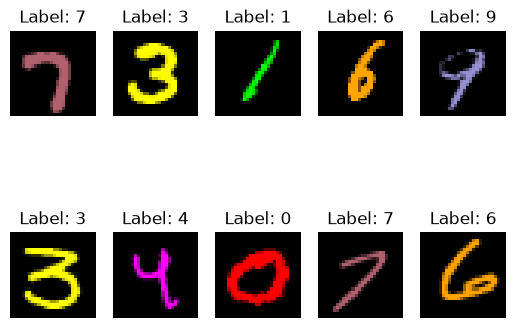

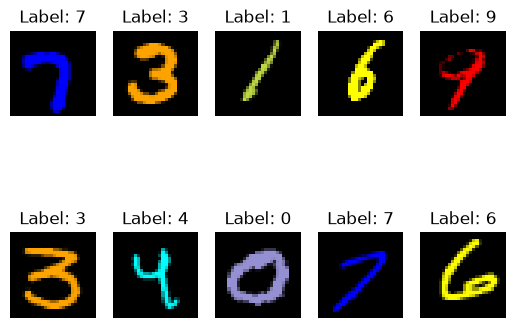

In [168]:
utils.show_from_dataset(val_dataset, range(0, 10))
utils.show_from_dataset(colors_flipped_val_dataset, range(0, 10))

In [169]:
for i in range(10):
	input, target = val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:-1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, sae_model.topk)
	print(f"Colors not flipped {i}: {indices}")

	input, target = colors_flipped_val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:-1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, sae_model.topk)
	print(f"Colors flipped {i}: {indices}")

Colors not flipped 0: tensor([[234,  20,  64, 245, 251]], device='mps:0')
Colors flipped 0: tensor([[174, 106, 253,  43,  50]], device='mps:0')
Colors not flipped 1: tensor([[201, 227,  75, 184, 173]], device='mps:0')
Colors flipped 1: tensor([[201, 184,  75, 227, 118]], device='mps:0')
Colors not flipped 2: tensor([[ 33, 158, 125,  19,  75]], device='mps:0')
Colors flipped 2: tensor([[  1, 237,  99, 166,  75]], device='mps:0')
Colors not flipped 3: tensor([[101, 247, 117, 102, 124]], device='mps:0')
Colors flipped 3: tensor([[247, 101, 102, 227, 201]], device='mps:0')
Colors not flipped 4: tensor([[157, 222, 110,  67,  65]], device='mps:0')
Colors flipped 4: tensor([[162,  72,  87, 216, 105]], device='mps:0')
Colors not flipped 5: tensor([[201, 227,  75, 118, 173]], device='mps:0')
Colors flipped 5: tensor([[227, 201,  25,  75, 126]], device='mps:0')
Colors not flipped 6: tensor([[ 62, 178, 157, 254, 162]], device='mps:0')
Colors flipped 6: tensor([[  5, 191,  91, 164, 174]], device='

In [203]:
@torch.no_grad()
def get_representatives(cls_model, sae_model, dataloader, n_representatives=10):
	sae_hidden_dim = sae_model.hidden_dim

	top_values = torch.full((sae_hidden_dim, n_representatives), -float('inf'), device=device)

	representatives = torch.full((sae_hidden_dim, n_representatives), -1, dtype=torch.long, device=device)

	current_img_offset = 0

	for inputs, targets in tqdm.tqdm(dataloader):
		inputs = inputs.to(device)
		bs = inputs.size(0)
		
		embeddings = cls_model.fc[:-1](inputs)
		
		output, hidden = sae_model(embeddings)
		
		batch_indices = torch.arange(current_img_offset, current_img_offset + bs, device=device)
		
		batch_hidden = hidden.T 
		
		# Create dataset indices for the current batch
		batch_indices = batch_indices.unsqueeze(0).expand(sae_hidden_dim, bs)
		
		# Concatenate the running top N with the new batch
		combined_values = torch.cat([top_values, batch_hidden], dim=1)
		combined_indices = torch.cat([representatives, batch_indices], dim=1)
		
		# Find the global winners so far
		top_values, topk_args = torch.topk(combined_values, k=n_representatives, dim=1)
		
		# Gather the winning image indices
		representatives = torch.gather(combined_indices, dim=1, index=topk_args)
		
		current_img_offset += bs

	return representatives

In [211]:
n_representatives = 10

val_representatives = get_representatives(model, sae_model, val_dataloader, n_representatives)
colors_flipped_val_representatives = get_representatives(model, sae_model, colors_flipped_val_dataloader, n_representatives)

100%|██████████| 375/375 [00:02<00:00, 173.32it/s]


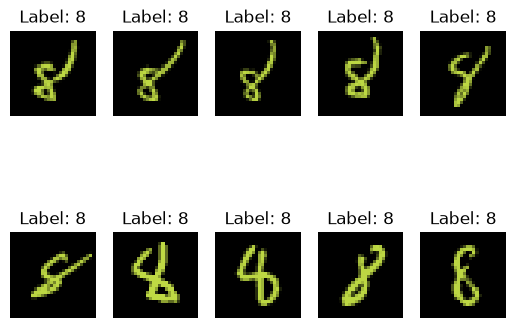

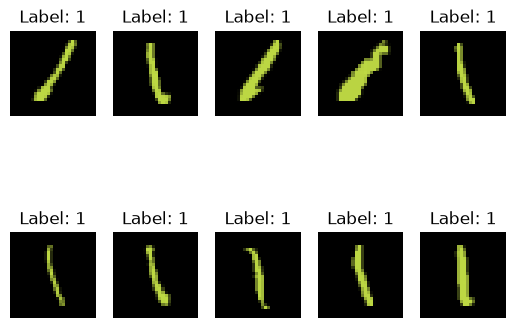

In [232]:
neuron_idx = 1

utils.show_from_dataset(val_dataset, val_representatives[neuron_idx].tolist())
utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[neuron_idx].tolist())

In [255]:
img_idx = val_representatives[1][0]

val_inputs, val_target = val_dataset[img_idx]
batched_val_inputs = val_inputs.to(device).unsqueeze(0)
val_embedding = model.fc[:-1](batched_val_inputs)
val_cls_output = model(batched_val_inputs)
print(f"Predicted class for val sample: {torch.argmax(val_cls_output)}")

flipped_val_inputs, flipped_val_target = colors_flipped_val_dataset[img_idx]
batched_flipped_val_inputs = flipped_val_inputs.to(device).unsqueeze(0)
flipped_embedding = model.fc[:-1](batched_flipped_val_inputs)
flipped_cls_output = model(batched_flipped_val_inputs)
print(f"Predicted class for val sample with flipped colors: {torch.argmax(flipped_cls_output)}")

Predicted class for val sample: 8
Predicted class for val sample with flipped colors: 1


# Encoding and embedding modification for val dataset (without flipped colors)

In [259]:
val_hidden = sae_model.encode(val_embedding)
val_hidden_values, val_hidden_indices = torch.topk(val_hidden, SAE_TOPK)
print(f"{val_hidden_values=}")
print(f"{val_hidden_indices=}")

val_hidden_values=tensor([[5.3962, 3.7589, 2.9531, 2.6105, 2.1217]], device='mps:0',
       grad_fn=<TopkBackward0>)
val_hidden_indices=tensor([[  1,  12, 237, 188,  75]], device='mps:0')


In [260]:
modified_val_hidden = val_hidden
modified_val_hidden[0, val_hidden_indices[0]] = 0

modified_hidden_values, modified_hidden_indices = torch.topk(modified_val_hidden, SAE_TOPK)
print(f"{modified_hidden_values=}")
print(f"{modified_hidden_indices=}")

modified_hidden_values=tensor([[2.1205, 2.0056, 1.5723, 1.5471, 1.4521]], device='mps:0',
       grad_fn=<TopkBackward0>)
modified_hidden_indices=tensor([[101, 166, 160, 248, 121]], device='mps:0')


Representatives for neuron: 101


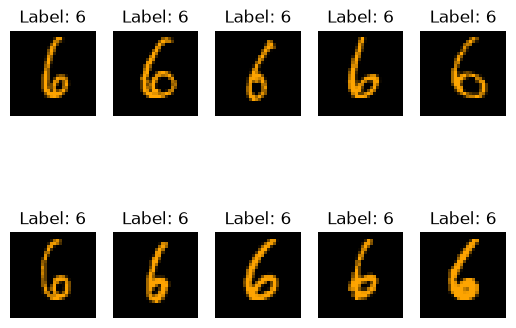

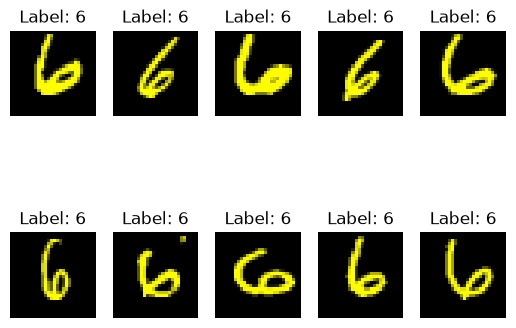

Representatives for neuron: 166


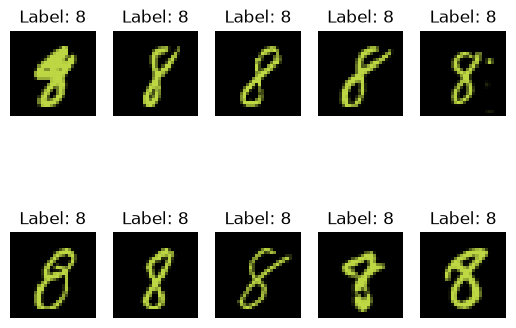

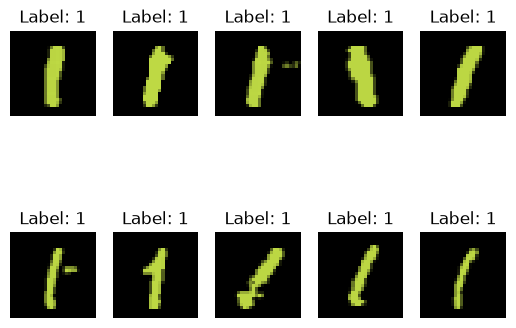

Representatives for neuron: 160


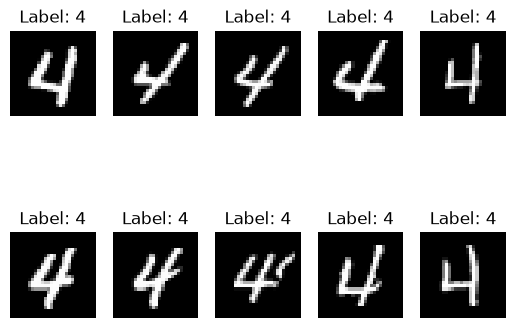

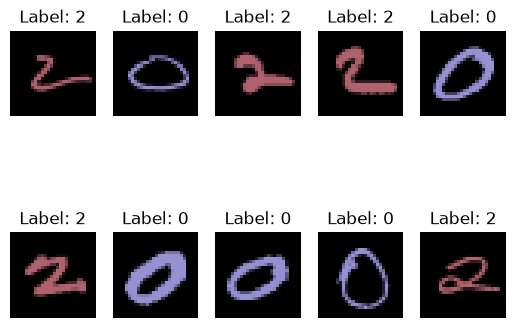

Representatives for neuron: 248


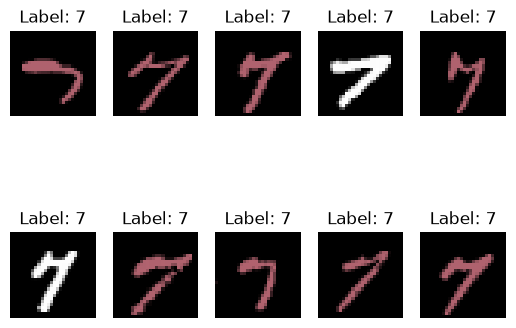

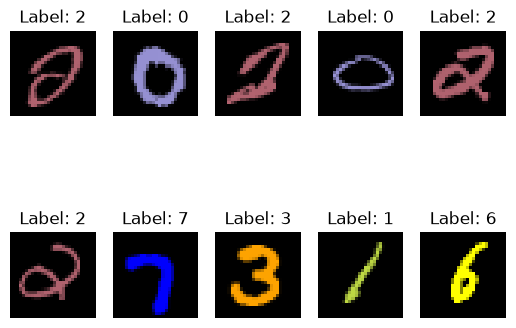

Representatives for neuron: 121


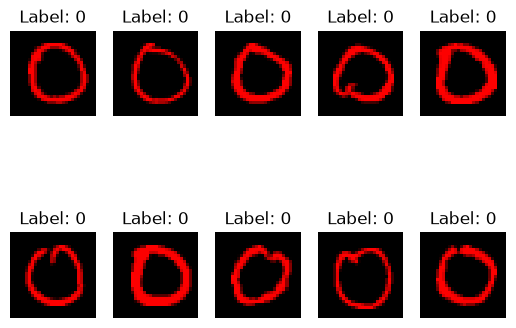

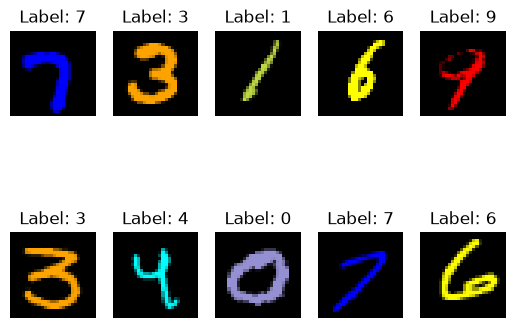

In [258]:
for neuron_idx in modified_hidden_indices.flatten().tolist():
	print(f"Representatives for neuron: {neuron_idx}")
	utils.show_from_dataset(val_dataset, val_representatives[neuron_idx].tolist())
	utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[neuron_idx].tolist())

In [261]:
decoded_embedding = sae_model.decode(modified_val_hidden)
new_output = model.fc[-1](decoded_embedding)
print(f"New predicted class for val sample: {torch.argmax(new_output)}")

New predicted class for val sample: 8


# Encoding and embedding modification for val dataset with flipped colors

In [264]:
flipped_hidden = sae_model.encode(flipped_embedding)
flipped_hidden_values, flipped_hidden_indices = torch.topk(flipped_hidden, SAE_TOPK)
print(f"{flipped_hidden_values=}")
print(f"{flipped_hidden_indices=}")

flipped_hidden_values=tensor([[4.6121, 3.9925, 3.7965, 2.7094, 2.5462]], device='mps:0',
       grad_fn=<TopkBackward0>)
flipped_hidden_indices=tensor([[ 33, 125,  19, 191,  75]], device='mps:0')


Representatives for neuron: 33


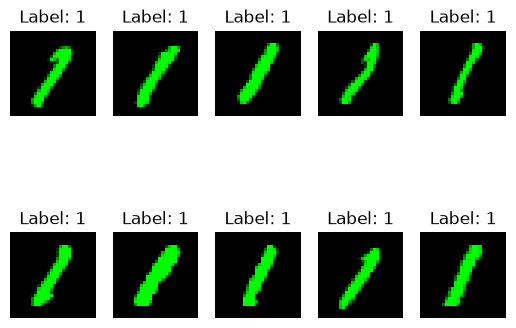

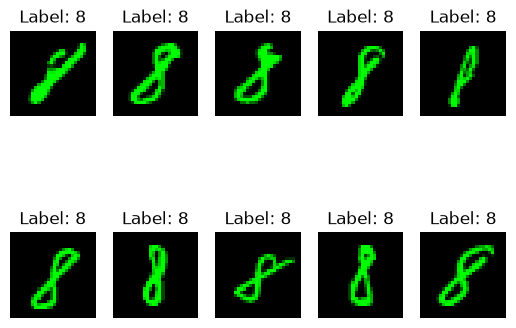

Representatives for neuron: 125


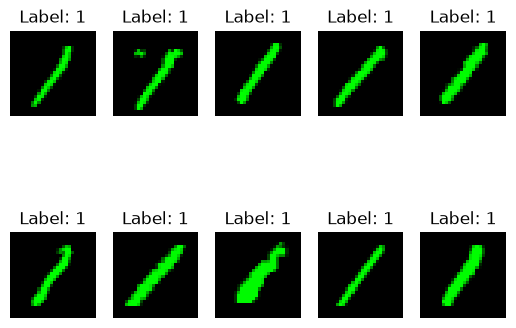

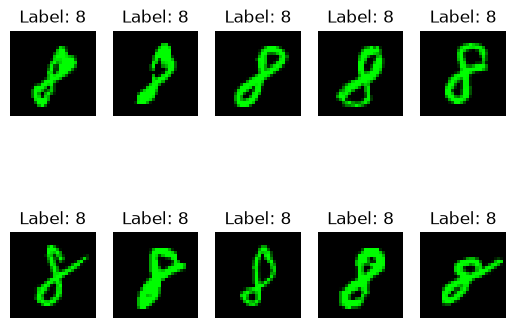

Representatives for neuron: 19


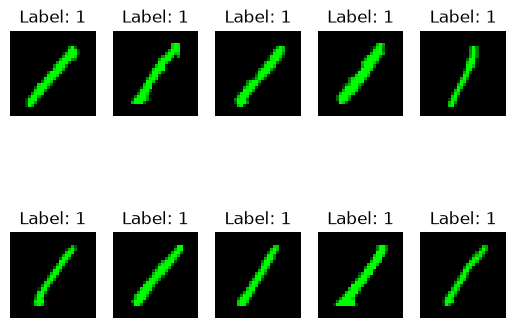

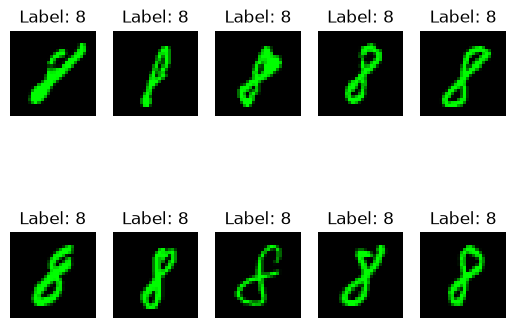

Representatives for neuron: 191


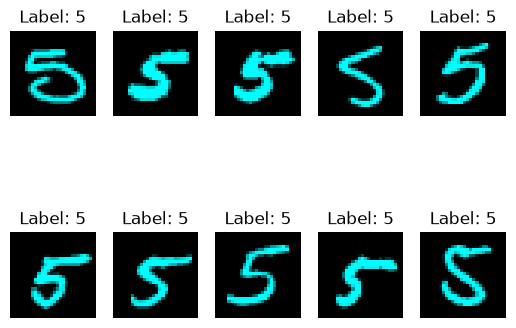

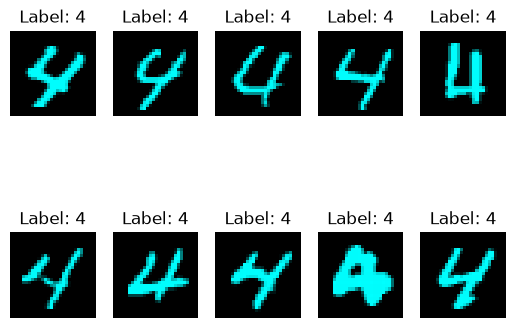

Representatives for neuron: 75


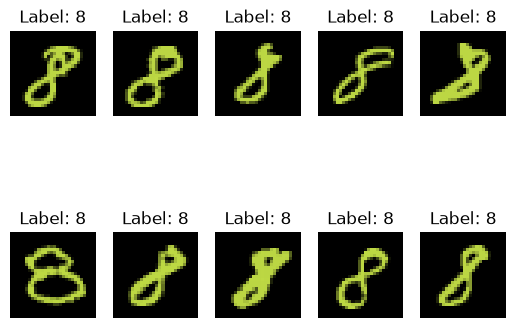

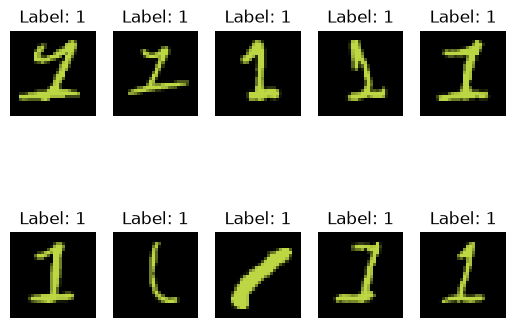

In [265]:
for neuron_idx in flipped_hidden_indices.flatten().tolist():
	print(f"Representatives for neuron: {neuron_idx}")
	utils.show_from_dataset(val_dataset, val_representatives[neuron_idx].tolist())
	utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[neuron_idx].tolist())

In [266]:
modified_flipped_hidden = flipped_hidden
modified_flipped_hidden[0, [33, 125, 19]] = 0

modified_flipped_hidden_values, modified_flipped_hidden_indices = torch.topk(modified_flipped_hidden, SAE_TOPK)
print(f"{modified_flipped_hidden_values=}")
print(f"{modified_flipped_hidden_indices=}")

modified_flipped_hidden_values=tensor([[2.7094, 2.5462, 2.4816, 2.0857, 1.8482]], device='mps:0',
       grad_fn=<TopkBackward0>)
modified_flipped_hidden_indices=tensor([[191,  75, 158, 166, 230]], device='mps:0')


Representatives for neuron: 191


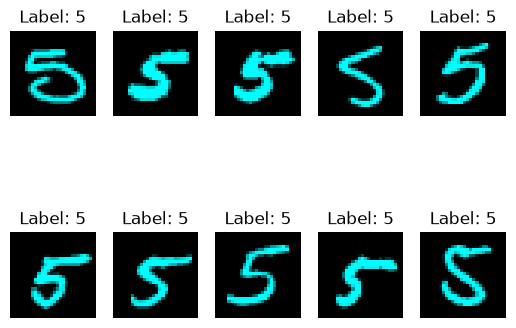

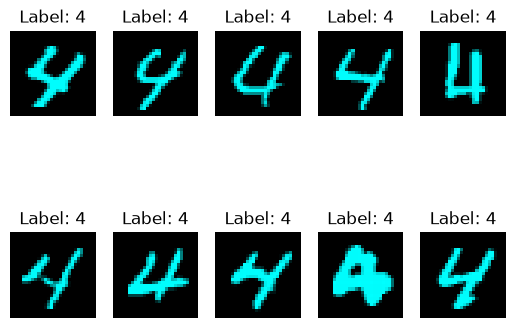

Representatives for neuron: 75


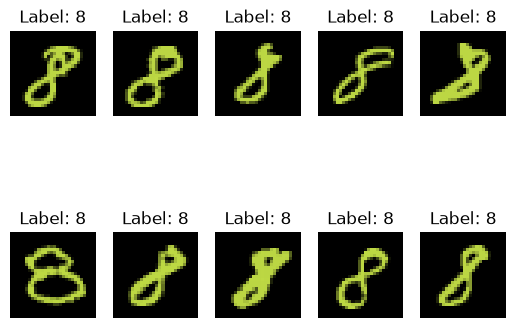

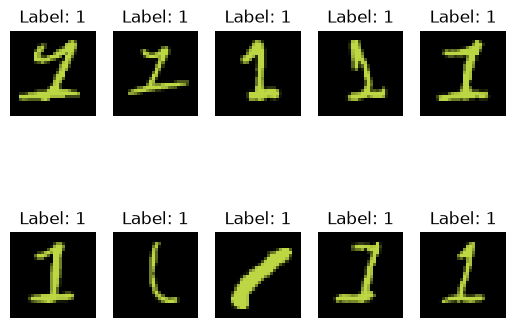

Representatives for neuron: 158


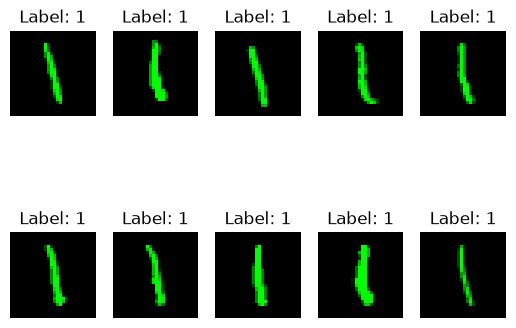

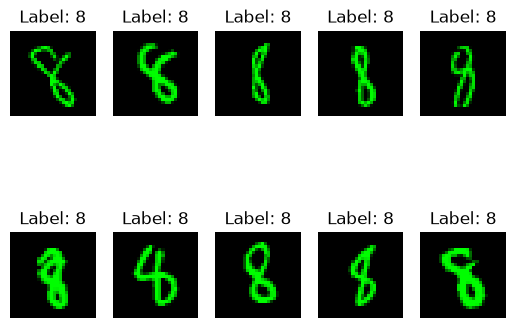

Representatives for neuron: 166


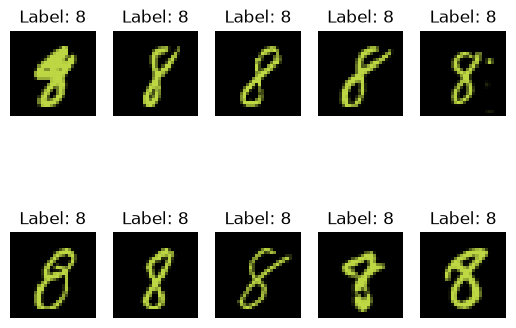

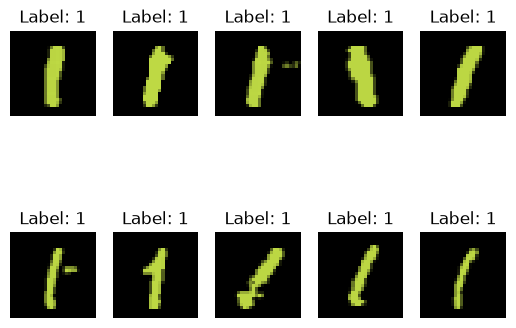

Representatives for neuron: 230


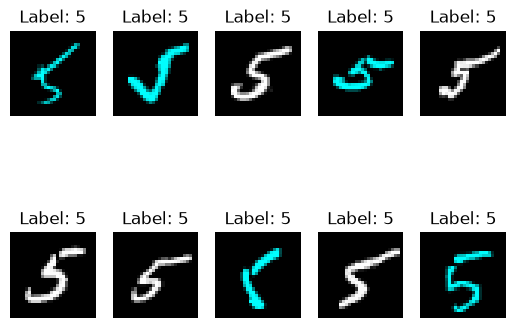

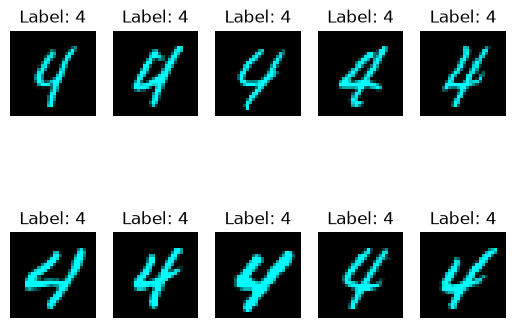

In [268]:
for neuron_idx in modified_flipped_hidden_indices.flatten().tolist():
	print(f"Representatives for neuron: {neuron_idx}")
	utils.show_from_dataset(val_dataset, val_representatives[neuron_idx].tolist())
	utils.show_from_dataset(colors_flipped_val_dataset, colors_flipped_val_representatives[neuron_idx].tolist())

In [269]:
decoded_flipped_embedding = sae_model.decode(modified_flipped_hidden)
new_flipped_output = model.fc[-1](decoded_flipped_embedding)
print(f"New predicted class for val sample with flipped colors: {torch.argmax(new_flipped_output)}")

New predicted class for val sample with flipped colors: 8
